In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

import os
os.getcwd()

NUM_CORES = os.cpu_count()
print('CPU Cores:', NUM_CORES)

CPU Cores: 12


In [2]:
#Load Data into DataFrames
test = pd.read_csv(r'Data\test.csv', index_col = 0)
train = pd.read_csv(r'Data\train.csv', index_col = 0)
print(test.head())
print(train.head())
data = [train, test]

            HomePlanet CryoSleep  Cabin  Destination   Age    VIP  \
PassengerId                                                         
0013_01          Earth      True  G/3/S  TRAPPIST-1e  27.0  False   
0018_01          Earth     False  F/4/S  TRAPPIST-1e  19.0  False   
0019_01         Europa      True  C/0/S  55 Cancri e  31.0  False   
0021_01         Europa     False  C/1/S  TRAPPIST-1e  38.0  False   
0023_01          Earth     False  F/5/S  TRAPPIST-1e  20.0  False   

             RoomService  FoodCourt  ShoppingMall     Spa  VRDeck  \
PassengerId                                                         
0013_01              0.0        0.0           0.0     0.0     0.0   
0018_01              0.0        9.0           0.0  2823.0     0.0   
0019_01              0.0        0.0           0.0     0.0     0.0   
0021_01              0.0     6652.0           0.0   181.0   585.0   
0023_01             10.0        0.0         635.0     0.0     0.0   

                         Name  


In [3]:
#Data Cleaning
for df in data:
    print(df.isna().sum())
    print('----------Next----------')
    
#drop na rows for now
train = train.dropna()
test = test.dropna()

#drop name column
train = train.drop(columns = ['Name'])
test = test.drop(columns = ['Name'])

HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64
----------Next----------
HomePlanet       87
CryoSleep        93
Cabin           100
Destination      92
Age              91
VIP              93
RoomService      82
FoodCourt       106
ShoppingMall     98
Spa             101
VRDeck           80
Name             94
dtype: int64
----------Next----------


In [4]:
#Data Preprocessing
num_cols = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'TotalSpent']
cat_cols = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP']



def preprocess_data(df, num_cols, cat_cols):
    # Drop rows with missing values
    df.dropna(inplace=True)
    
    # Separate the cabin columns into 3 different columns
    df[['Deck', 'Roomnumber', 'Side']] = df['Cabin'].str.split('/', expand=True)
    
    # Convert Roomnumber to numerical
    df['Roomnumber'] = pd.to_numeric(df['Roomnumber'], errors='coerce')
    
    # Add a combined spent column to gauge how much a passenger spent
    df['TotalSpent'] = df['RoomService'] + df['FoodCourt'] + df['ShoppingMall'] + df['Spa'] + df['VRDeck']
    
    # Standardize numerical columns
    scaler = StandardScaler()
    scaled_cols = scaler.fit_transform(df[num_cols + ['Roomnumber']])
    scaled_df = pd.DataFrame(scaled_cols, columns=num_cols + ['Roomnumber'], index=df.index)
    
    # One-hot encode categorical columns including Deck and Side
    encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    encoded_cols = encoder.fit_transform(df[cat_cols + ['Deck', 'Side']])
    encoded_df = pd.DataFrame(encoded_cols, columns=encoder.get_feature_names_out(cat_cols + ['Deck', 'Side']), index=df.index)
    
    # Concatenate the scaled and encoded columns with the original DataFrame
    df = pd.concat([df, scaled_df, encoded_df], axis=1)
    
    # Drop old columns
    df.drop(columns=num_cols + cat_cols + ['Deck', 'Side', 'Cabin'], inplace=True)
    
    return df
    
    
p_test = preprocess_data(test, num_cols, cat_cols)
p_train = preprocess_data(train, num_cols, cat_cols)
print(f'test_shape: {p_train.shape}')
print(f'p_test_shape: {p_test.shape}')

    



test_shape: (6606, 23)
p_test_shape: (3281, 22)


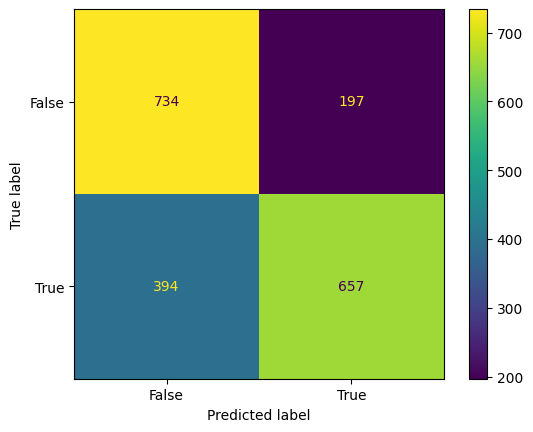

Best parameters found:  {'var_smoothing': 1e-06}
Best cross-validation score:  0.716267425878657


In [5]:
#Bayes Classifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

#create train test split
X = p_train.drop(columns=['Transported'])
y = p_train['Transported']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 117)

NB = GaussianNB()

param_grid = {
    'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1]
}

GS = GridSearchCV(NB, param_grid, cv = 10, scoring = 'accuracy', n_jobs = NUM_CORES)

GS.fit(X_train, y_train)

Best_NB = GS.best_estimator_


y_pred = Best_NB.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=Best_NB.classes_)
disp.plot()
plt.show()

print("Best parameters found: ", GS.best_params_)
print("Best cross-validation score: ", GS.best_score_)


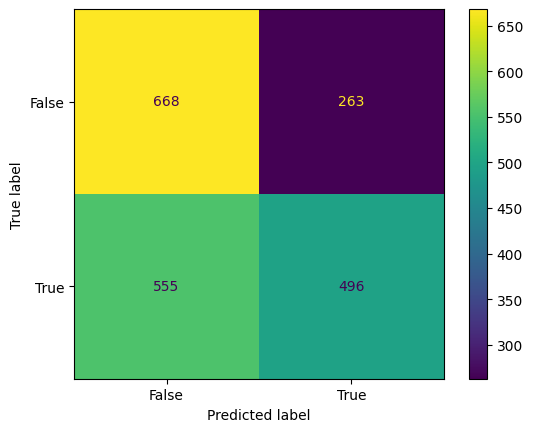

Best parameters found:  {'n_neighbors': 12}
Best cross-validation score:  0.594068422578142


In [6]:
#kNN Classifier
from sklearn.neighbors import KNeighborsClassifier

kNN = KNeighborsClassifier()
param_grid = {
    'n_neighbors': range(1, 500)
}

GS = GridSearchCV(kNN, param_grid, cv = 10, scoring = 'accuracy', n_jobs = NUM_CORES) #use all cores so its a bit faster
GS.fit(X_train, y_train)
Best_kNN = GS.best_estimator_
y_pred = Best_kNN.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=Best_kNN.classes_)
disp.plot()
plt.show()

print("Best parameters found: ", GS.best_params_)
print("Best cross-validation score: ", GS.best_score_)

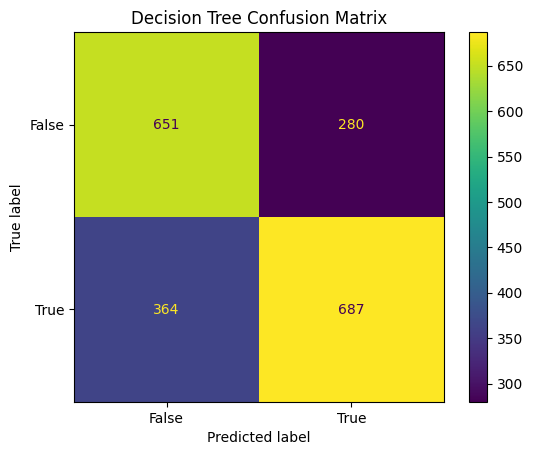

Decision Tree Accuracy: 0.6750756811301716


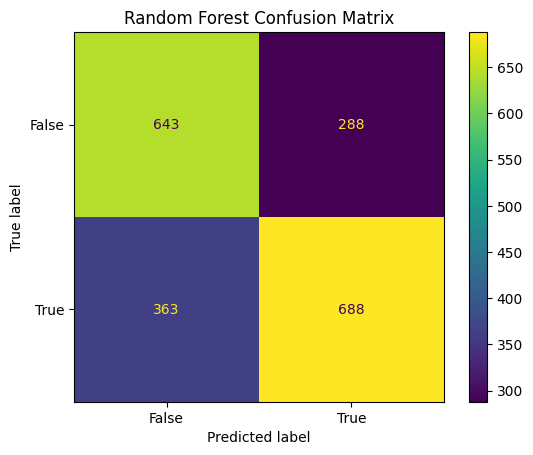

Random Forest Accuracy: 0.6715438950554995


In [7]:
#Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

DT = DecisionTreeClassifier()

DT.fit(X_train, y_train)
y_pred = DT.predict(X_test)
cm = confusion_matrix(y_test, y_pred)  
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=DT.classes_)
disp.plot()
plt.title("Decision Tree Confusion Matrix")
plt.show()
accuracy_dt = accuracy_score(y_test, y_pred)
print(f"Decision Tree Accuracy: {accuracy_dt}")


#Random Forest Classifier
RF = RandomForestClassifier()
RF.fit(X_train, y_train)
y_pred = RF.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=RF.classes_)
disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()
accuracy_rf = accuracy_score(y_test, y_pred)
print(f"Random Forest Accuracy: {accuracy_rf}")


In [9]:
#Use best model so far to predict test set for submission csv
y_test_pred = Best_NB.predict(p_test)
submission = pd.DataFrame({'PassengerId': test.index, 'Transported': y_test_pred})
submission.to_csv('submission.csv', index=False)